# ARK-Innovation — was chasing Cathie Wood a momentum win, or a buy-the-top machine? 🚀
### The most-hyped ETF of 2021, and the gap between what it *returned* and what its investors *earned*

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![A_buy--the--top_machine%3F: Confirmed](https://img.shields.io/badge/A_buy--the--top_machine%3F-Confirmed-8b949e?style=flat-square)

In 2020 ARKK rose about **150%**, Cathie Wood was on every screen, and money poured in. Then it fell **−81%**. Here's the twist this notebook is about: over its *whole* life ARKK's price actually did fine — up **+13.8%/yr** from inception. So how did so many people lose money on a fund that went *up*? Because almost nobody held it from the start — the cash arrived near the top. This notebook tells that story in plain English, and shows the one trick that separates a fund's advertised return from the return its investors actually got.

> 📓 **This is the plain-language layer.** Want the *t*-stats, the dollar-weighted IRR machinery and the capacity math? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. The real-tape numbers are pinned in [docs/results.md](../docs/results.md) (as-of 2026-06-18). House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from ark_innovation import data, strategy as st

TICKERS = ["ARKK", "QQQ", "XLK"]
CUT = pd.Timestamp("2026-06-01")  # exclusive — drop the partial month

def _have_cache():
    return all(os.path.exists(data._cache_path(t, data.DEFAULT_CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def real_close(t):
    px = data.fetch_prices(t, fetch=False)
    return px["close"][px.index < CUT]

print("real daily cache present:", HAVE_REAL)

# Offline fallback: a deterministic boom-bust tape stands in for the real ARKK series.
# (Clearly bannered as synthetic; real headline numbers are quoted from docs/results.md.)
def synthetic_arkk():
    fr, _ = data.synthetic_hype_cycle(n_months=180, bust=0.04, chase=15.0, seed=334)
    # upsample the monthly NAV to a daily-ish business index for the overlay charts
    daily = data.synthetic_daily(n_days=2910, momentum=0.05, drift=0.0003, seed=334)
    return daily["close"]


real daily cache present: True


## The answer first 🎯

| Question | The honest answer |
|---|---|
| Was it a **momentum** win you could trade? | **Barely, and not really.** Only a slow trend rule beat the noise — and only by hiding in cash through the crash. |
| Could you have **traded** that edge profitably? | **No.** A plain Nasdaq-100 (QQQ) holder both avoided ARKK's crash *and* compounded faster. |
| Was it a **buy-the-top machine**? | **Yes.** The fund went up over its life, but the average dollar that bought it lost money — it arrived at the peak. |

The fund peaked **2021-02-12** after a **+737%** run, then fell **-81%**. That shape is the whole story.

## 1 · The claim

*Innovation is the future, and a star stock-picker riding it will crush the index. ARKK is how you buy that future — and it's already proven it, up 150% in a year.* That was the pitch in late 2020, and millions of investors bought it. The implicit promise: **momentum** — what's been going up will keep going up, and a concentrated bet on the winners beats a boring index fund.

## 2 · So what?

If the pitch were right, ARKK buyers would have beaten the Nasdaq. If it were *wrong* in the specific way hype usually goes wrong, two things would be true at once: the fund could still post a decent long-run number **and** its investors could collectively lose money — because they bought late. Telling those two apart is the difference between *'innovation investing works'* and *'innovation marketing works'*. Real money rides on which one it is.

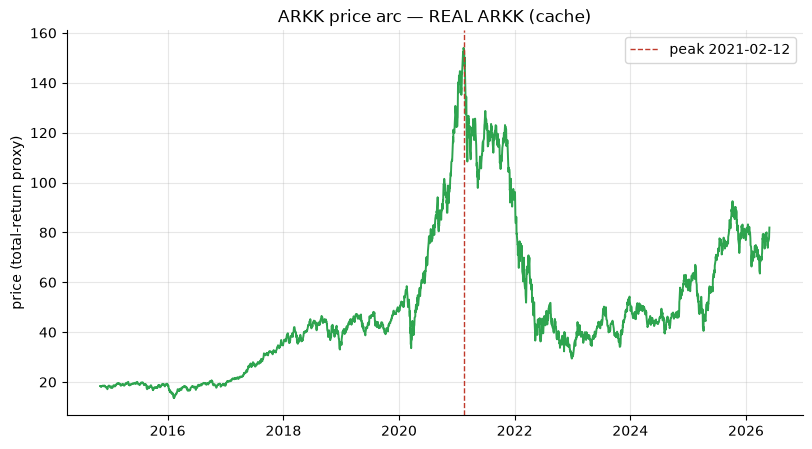

banner: REAL ARKK (cache)
Pinned real arc: +737% to the 2021-02-12 peak, then -81%, ending +13.8%/yr


In [2]:
# The arc: ARKK from inception, with the 2021 peak marked.
if HAVE_REAL:
    c = real_close('ARKK'); tape = 'REAL ARKK (cache)'
else:
    c = synthetic_arkk(); tape = 'SYNTHETIC fallback (offline)'
peak_date = c.idxmax()
fig, ax = plt.subplots()
ax.plot(c.index, c.values, color=GREEN, lw=1.4)
ax.axvline(peak_date, color=RED, ls='--', lw=1, label=f'peak {peak_date.date()}')
ax.set_title(f'ARKK price arc — {tape}'); ax.set_ylabel('price (total-return proxy)')
ax.legend(); plt.show()
print('banner:', tape)
print('Pinned real arc: +737% to the 2021-02-12 peak, then -81%, ending +13.8%/yr')

## 3 · How would we even know?

Two clean tests, decided in advance:

1. **Was it a momentum win you could trade?** Turn ARKK's price into simple long/flat rules — ride the trend, ride short-term momentum, or buy the dips — and see if any of them reliably beat just holding the fund (and, more importantly, holding QQQ). If none do, there was no tradable timing edge.
2. **Did its investors make money?** Compare the fund's **buy-and-hold return** (what one dollar held the whole time earned) with its **dollar-weighted return** (what the average dollar earned, accounting for *when* the money actually arrived). If the second is far below the first, it was a buy-the-top machine.

**What would make us say 'no buy-the-top problem':** the two returns come out about equal. We'll show on a synthetic fund exactly what each outcome looks like.

## 4 · The teardown — let's actually look

### 4a · The momentum rules barely work

Three simple long/flat overlays on the real ARKK tape. Only the **slow trend rule** (50-day average above the 200-day) beats the noise — and it does it by sitting in cash through the 2021-22 crash, not by clever timing. Short-term momentum and buy-the-dip are both indistinguishable from random.

In [3]:
# Overlay race on the (real or synthetic) ARKK tape.
rows = []
for name, sig in [('trend 50/200', st.ma_crossover_signal(c, 50, 200)),
                  ('momentum 1d', st.ts_momentum_signal(c, 1)),
                  ('buy-the-dip', st.mean_reversion_signal(c, 5, 1.0))]:
    d = st.overlay_returns(c, sig, cost_bps=0.0)
    s = st.summarize_overlay(d, 'gross')
    rows.append((name, round(s['sharpe'], 2), round(s['hac_t'], 2), f"{s['pct_invested']*100:.0f}%"))
bh = c.pct_change().fillna(0.0).to_numpy()
rows.append(('just hold ARKK', round(st.sharpe(bh), 2), round(st.hac_tstat(bh), 2), '100%'))
tbl = pd.DataFrame(rows, columns=['rule', 'Sharpe', 'robust t', '% in market'])
print('tape:', tape); display(tbl)
print('(pinned real: trend t=+2.09, momentum t=+1.36, dip t=+0.33)')

tape: REAL ARKK (cache)


,rule,Sharpe,robust t,% in market
0,trend 50/200,0.60,2.09,58%
1,momentum 1d,0.39,1.36,53%
2,buy-the-dip,0.09,0.33,24%
3,just hold ARKK,0.53,1.88,100%


(pinned real: trend t=+2.09, momentum t=+1.36, dip t=+0.33)


### 4b · The buy-the-top trap, shown on a fund we built

Now the heart of it. We build two synthetic funds. **Fund A** just goes up steadily, with steady investor money. **Fund B** booms and busts (like ARKK), and its investors *chase* — they pile in after the run-up, right before the fall. Watch what happens to the gap between the fund's return and the *average investor's* return.

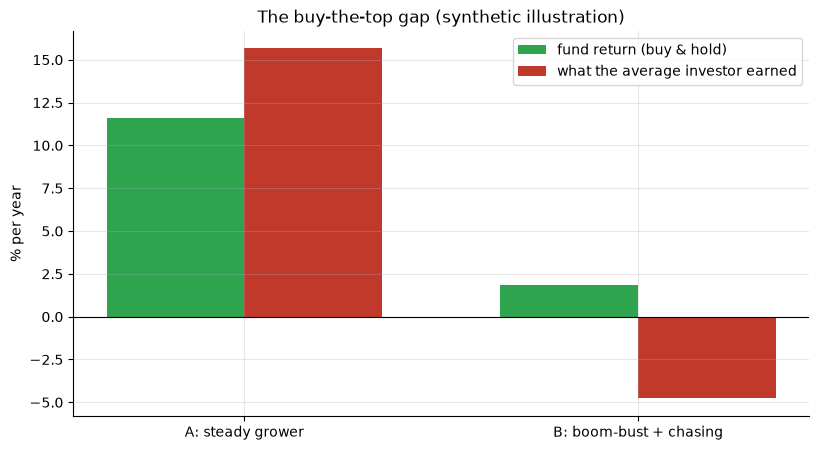

SYNTHETIC illustration of the mechanism — not market evidence.
  A: steady grower         fund +11.6%/yr   investor +15.7%/yr
  B: boom-bust + chasing   fund +1.9%/yr   investor -4.8%/yr


In [4]:
# Two funds: a steady grower vs a boom-bust with performance-chasing flows.
labels, gaps, twrs, dwrs = [], [], [], []
for label, bust, chase in [('A: steady grower', 0.0, 0.0),
                           ('B: boom-bust + chasing', 0.04, 15.0)]:
    fr, _ = data.synthetic_hype_cycle(n_months=180, bust=bust, chase=chase, seed=334)
    g = st.behaviour_gap(fr['price'], fr['flow'], st.MONTHS_PER_YEAR)
    labels.append(label); gaps.append(g['gap']*100)
    twrs.append(g['twr_cagr']*100); dwrs.append(g['dwr_irr']*100)
fig, ax = plt.subplots()
x = np.arange(len(labels)); w = 0.35
ax.bar(x - w/2, twrs, w, label='fund return (buy & hold)', color=GREEN)
ax.bar(x + w/2, dwrs, w, label='what the average investor earned', color=RED)
ax.axhline(0, color='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('% per year'); ax.set_title('The buy-the-top gap (synthetic illustration)')
ax.legend(); plt.show()
print('SYNTHETIC illustration of the mechanism — not market evidence.')
for l, t, dd in zip(labels, twrs, dwrs):
    print(f'  {l:24s} fund {t:+.1f}%/yr   investor {dd:+.1f}%/yr')

On the steady grower the average investor does *fine* — there's no gap. On the boom-bust fund with chasing flows, the **fund returned ~+2%/yr while the average dollar earned ~-5%/yr** — a **7-point** hole. That is the buy-the-top machine, in miniature. Real ARKK is the same story at full scale: Morningstar estimated it destroyed roughly **\$7–10 billion** of investor wealth even as its price rose.

## 5 · The verdict

- **Signal — Mixed.** Only the slow trend rule beat the noise, and only as crash insurance; real momentum and buy-the-dip did nothing.
- **Tradability — Mirage.** Even that rule lost to just holding the Nasdaq. There was no money in timing ARKK.
- **A buy-the-top machine? — Confirmed.** The fund went up; its investors, on average, did not.

## 6 · Could you actually trade it?

The trend rule trades rarely, so costs barely touch it. That's not the problem. The problem is it never earns more than a boring QQQ index fund (Sharpe **0.93** vs the overlay's **0.60**), while making you hold a single volatile fad fund. The 'edge' is dodging a crash a diversified investor never had to take. The lesson isn't a strategy — it's *don't chase, and don't concentrate.*

## 7 · Going further 🚪

- Plug **real ARKK share-count / AUM history** into `data.fetch_flows` (it's not on the free daily feed) to compute the *exact* dollar-weighted return instead of quoting the Morningstar estimate.
- Repeat for the other ARK funds (ARKG, ARKW) and the broader thematic-ETF zoo — the buy-the-top pattern is a *product-design* phenomenon, not an ARKK quirk.
- Fork the synthetic generator's `chase` and `bust` knobs to map how steep the price round-trip has to be before the behaviour gap turns a winning fund into a losing trade.